# 04 — Phase 2: MERT Embeddings + Clustering

**MERT-v1-330M** — trained on 160k hours of music with masked audio modeling.
No genre labels, no text alignment. Embeddings reflect perceptual acoustic content.

First run downloads ~1.3 GB from HuggingFace. Subsequent runs use local cache.

**Requires audio files**: personal MP3s in `PERSONAL_DIR`
and/or FMA small in `../data/audio/fma_small/`

Embeddings use **all-layer aggregation + multi-window pooling + EBU R128 loudness
normalization** (Workstreams E & I). Clustering uses **Leiden** (Workstream D);
2D UMAP is visualization only. The embedding config is recorded in the index so
indices built with different settings can't be mixed.

⚠️ Embedding 8k FMA tracks takes hours on MPS. Start with the personal library
only to validate the approach first.

In [ ]:
import sys
sys.path.insert(0, '..')  # optional now that anther_ml is `pip install -e .`

import numpy as np
import pickle
from pathlib import Path

from anther_ml.embedding import load_mert, get_embedding, embed_batch, embedding_config
from anther_ml.cluster import fit_clusters_leiden, save_leiden, resolution_sweep
from anther_ml.similarity import SongIndex
from anther_ml.data import load_fma_tracks, get_audio_path
from anther_ml import eval as ev

PERSONAL_DIR  = Path('/Volumes/MRRW/songs_anther')
FMA_AUDIO_DIR = Path('../data/audio/fma_small')
METADATA_DIR  = '../data/fma_metadata'

# ── Phase-2 embedding config (Workstreams E & I) ─────────────────────────────
LAYER_AGG = 'mean'   # 'mean' = all-layer aggregation; 'last' = old single-layer
NORMALIZE = True     # EBU R128 loudness normalization before inference
# Neural embeddings are often best with plain L2+cosine, so DON'T z-score the
# index by default for Phase 2 — let the eval harness decide (set True to test).
STANDARDIZE = False

CFG = embedding_config(layer_aggregation=LAYER_AGG, normalize=NORMALIZE)
CFG['personal_dir'] = str(PERSONAL_DIR)
print('imports ok'); print('embedding config:', CFG)

## Load MERT model

In [17]:
model, processor, device = load_mert()
print(f'Running on: {device}')

Loading MERT-v1-330M on mps...


Loading weights:   0%|          | 0/403 [00:00<?, ?it/s]

MERT loaded.
Running on: mps


## Embed personal library first

Fast (seconds per song). Good for early validation.

In [ ]:
personal_paths = sorted(PERSONAL_DIR.glob('*.mp3')) + sorted(PERSONAL_DIR.glob('*.wav'))
print(f'Found {len(personal_paths)} personal tracks')

if len(personal_paths) == 0:
    print(f'Add MP3/WAV files to {PERSONAL_DIR} first!')
else:
    # embed_batch now processes one track at a time (each track is a mini-batch
    # of windows); no batch_size arg. Applies all-layer + multi-window + loudness.
    personal_embeddings, good_paths = embed_batch(
        model, processor, personal_paths, device,
        layer_aggregation=LAYER_AGG, normalize=NORMALIZE,
    )
    print(f'Personal embeddings shape: {personal_embeddings.shape}')

    # Record the source path so the index is reproducible (Workstream G).
    personal_metadata = [
        {'name': p.stem, 'artist': 'personal', 'genre': 'unknown',
         'source': 'personal', 'path': str(p)}
        for p in good_paths
    ]

    np.save('../models/personal_embeddings.npy', personal_embeddings)
    with open('../models/personal_metadata.pkl', 'wb') as f:
        pickle.dump(personal_metadata, f)
    print(f'Saved {len(good_paths)} embeddings.')

## Embed FMA small (optional — takes a while)

Skip this cell if you only have personal tracks for now.
Come back to it once you've downloaded fma_small audio.

In [ ]:
EMBED_FMA = False  # ← set True when fma_small audio is downloaded

if EMBED_FMA:
    tracks = load_fma_tracks(METADATA_DIR)
    # fma_small = the 8,000 tracks labeled 'small' (NOT string '<=', which
    # matched all 106k — Workstream C).
    small = tracks[tracks[('set', 'subset')] == 'small']

    fma_paths, fma_meta_pre = [], []
    for tid in small.index:
        p = get_audio_path(FMA_AUDIO_DIR, tid)
        if p.exists() and not p.name.startswith('._'):
            fma_paths.append(p)
            fma_meta_pre.append({
                'track_id': tid,
                'name': small.loc[tid, ('track', 'title')],
                'artist': small.loc[tid, ('artist', 'name')],
                'genre': small.loc[tid, ('track', 'genre_top')],
                'source': 'fma',
                'path': str(p),
            })

    print(f'Found {len(fma_paths)} FMA audio files')
    print('Starting batch embedding (grab a coffee)...')

    fma_embeddings, good_fma_paths = embed_batch(
        model, processor, fma_paths, device,
        layer_aggregation=LAYER_AGG, normalize=NORMALIZE,
    )
    good_ids = {str(p) for p in good_fma_paths}
    fma_meta = [m for p, m in zip(fma_paths, fma_meta_pre) if str(p) in good_ids]

    np.save('../models/fma_embeddings.npy', fma_embeddings)
    with open('../models/fma_meta_phase2.pkl', 'wb') as f:
        pickle.dump(fma_meta, f)
    print(f'Done. Shape: {fma_embeddings.shape}')

## Combine and cluster

Cluster whatever you have — personal only, or personal + FMA.

⚠️ The existing `personal_embeddings.npy` on disk was built with the **old**
single-layer / no-loudness embedder. Re-run the embed cell above (with
`LAYER_AGG='mean'`, `NORMALIZE=True`) before combining, so the vectors match the
`CFG` recorded in the index. Never mix embeddings built with different configs.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load what's available
all_embeddings = []
all_metadata   = []

if Path('../models/personal_embeddings.npy').exists():
    emb = np.load('../models/personal_embeddings.npy')
    with open('../models/personal_metadata.pkl', 'rb') as f:
        meta = pickle.load(f)
    all_embeddings.append(emb)
    all_metadata.extend(meta)
    print(f'Personal: {emb.shape[0]} tracks')

if Path('../models/fma_embeddings.npy').exists():
    emb = np.load('../models/fma_embeddings.npy')
    with open('../models/fma_meta_phase2.pkl', 'rb') as f:
        meta = pickle.load(f)
    all_embeddings.append(emb)
    all_metadata.extend(meta)
    print(f'FMA: {emb.shape[0]} tracks')

X = np.vstack(all_embeddings)
print(f'\nTotal for clustering: {X.shape}')

Personal: 107 tracks

Total for clustering: (107, 1024)


In [ ]:
# Leiden on the MERT embedding (Workstream D). n_neighbors auto-scales with the
# corpus size; cosine metric on the graph. Sweep resolution first.
n = len(X)
print(f'Clustering {n} tracks with Leiden')

sweep = resolution_sweep(
    X, resolutions=(0.2, 0.5, 1.0, 1.5, 2.0),
    n_pca_components=min(50, n - 1), standardize=STANDARDIZE,
)
print(f'\n{"res":>5} | {"clusters":>8} | {"largest %":>9}')
print('-' * 30)
for s in sweep:
    print(f'{s["resolution"]:>5} | {s["n_clusters"]:>8} | {s["largest_cluster_frac"]*100:>8.1f}%')

# ── Pick after inspecting the sweep ───────────────────────────────────────────
RESOLUTION = 1.0
# ──────────────────────────────────────────────────────────────────────────────
out = fit_clusters_leiden(
    X, resolution=RESOLUTION, n_pca_components=min(50, n - 1), standardize=STANDARDIZE,
)
labels       = out['labels']
embedding_2d = out['embedding_2d']   # 2D UMAP — visualization only
scaler       = out['scaler']
pca          = out['pca']
reducer_2d   = out['reducer_2d']

n_clusters = out['diagnostics']['n_clusters']
print(f'\nClusters: {n_clusters},  largest '
      f'{out["diagnostics"]["largest_cluster_frac"]*100:.1f}% of tracks (no noise bucket)')

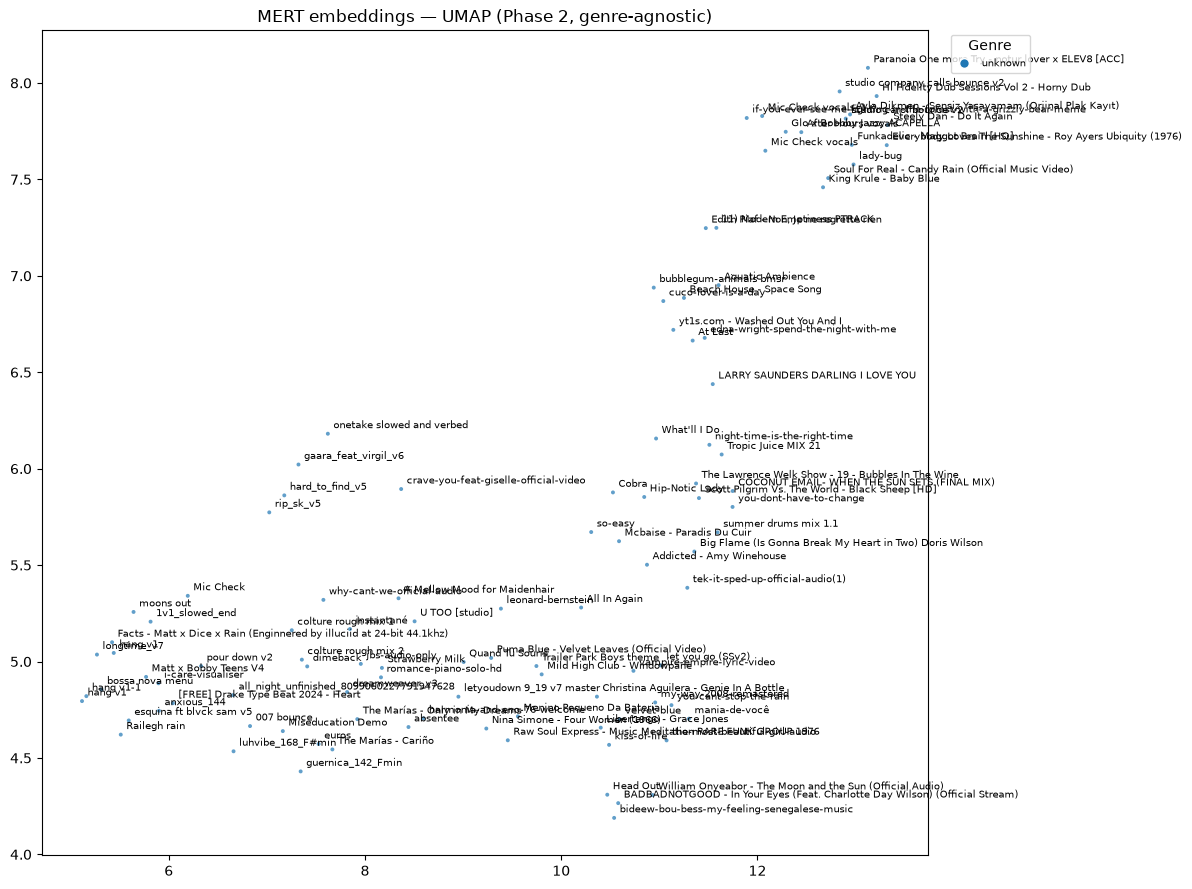

In [27]:
# Visualize
genre_labels = [m.get('genre', 'unknown') or 'unknown' for m in all_metadata]
unique_genres = sorted(set(genre_labels))
palette = sns.color_palette('tab20', n_colors=len(unique_genres))
g2c = {g: palette[i] for i, g in enumerate(unique_genres)}
colors = [g2c[g] for g in genre_labels]

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
           c=colors, s=8 if n > 100 else 40, alpha=0.7, linewidths=0)

# Label personal songs by name
for i, m in enumerate(all_metadata):
    if m.get('source') == 'personal':
        ax.annotate(m['name'], (embedding_2d[i, 0], embedding_2d[i, 1]),
                    fontsize=7, xytext=(4, 4), textcoords='offset points')

handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=g2c[g], markersize=7, label=g)
           for g in unique_genres]
ax.legend(handles=handles, title='Genre', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=7)
ax.set_title('MERT embeddings — UMAP (Phase 2, genre-agnostic)')
plt.tight_layout()
plt.savefig('../models/umap_phase2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save Leiden pipeline + index for notebook 05
save_leiden('../models/pipeline_phase2.pkl', out)

for i, m in enumerate(all_metadata):
    m['cluster'] = int(labels[i])

# Index carries the embedding config so incompatible indices can't be mixed.
index = SongIndex(X, all_metadata, standardize=STANDARDIZE, config=CFG)
index.save('../models/index_phase2')

np.save('../models/embedding_2d_phase2.npy', embedding_2d)
np.save('../models/labels_phase2.npy', labels)
print('Saved Leiden pipeline, index, 2D embedding.')

# Genre-free scorecard — self-retrieval on known related pairs (alternate mixes,
# stems, versions in the personal library). This is the primary Phase-2 metric.
card = ev.build_scorecard(index, labels=labels)
sr = card['self_retrieval']
print(f"\nrelated groups: {card['n_related_groups']}  (n_queries={sr['n_queries']})")
print(f"recall@1={sr['recall@1']:.3f}  recall@5={sr['recall@5']:.3f}  MRR={sr['mrr']:.3f}")
print(f"silhouette={card['silhouette']:.3f}  "
      f"largest_cluster={card['size_distribution']['largest_cluster_frac']:.1%}")
print("\nTip: re-run `python -m anther_ml.eval --index models/index_phase2 "
      "--audit-out models/audit_phase2` to dump a neighbor CSV/HTML for spot-listening.")